# Example usage of `vfp` with refl1d: Monolayer at solid-oil interface

To demonstrate the `vfp` we'll model some NR data taken with a Si substrate. 

Two NR contrasts were taken in a solid-liquid cell with dodecane ($\mathrm{C}_{12}\mathrm{H}_{26}$ \& $\mathrm{C}_{12}\mathrm{D}_{26}$).

Two other contrasts were taken with the same substrate with solutions of glycerol monooleate, a surfactant, in $\mathrm{C}_{12}\mathrm{H}_{26}$ \& $\mathrm{C}_{12}\mathrm{D}_{26}$.

In [1]:
import pathlib
import os
import matplotlib.pyplot as plt
import numpy as np
from functools import partial

from bumps.parameter import Parameter
import refl1d
from bumps.parameter import Parameter
from bumps.fitproblem import FitProblem 

from refl1d.experiment import Experiment
from refl1d.probe.resolution import sigma2FWHM
from refl1d.sample.material import SLD, Material
from refl1d.sample.layers import Slab, Stack
from refl1d.probe import NeutronProbe

import vfp

In [2]:
def qt2l(q: np.ndarray, t: float) -> np.ndarray:
    """
    Get wavelength from q and theta.
    """
    return 4 * np.pi * np.sin(np.radians(t)) / q

def tof_loader(filename: str | pathlib.Path,
               t: float = 0.7, 
               dqoq: float = 0.03, 
               delimiter: str = "\t", 
               **kw) -> NeutronProbe:
    """
    Create `NeutronProbe.refl1d.probe` for each file, with given parameters.
    
    Parameters
    ----------
    filename: str | pathlib.Path
        Name of data file to load.
    t: float
        Incident angle data was collected with.
    dqoq: float
        Resolution data was collected with (sigma not FWHM).
    delimiter: str
        The delimiter between data entries in data file.
    """
    q, r, dr = np.loadtxt(filename, delimiter=delimiter).T
    data_in = (r, dr)
    
    l = qt2l(q, t)
    # Convert the dq/q resolution into a dq value for each Q point
    dq = q * dqoq # refl1d works in sigma, not FWHM.

    probe_out = NeutronProbe(
        T=t, 
        dT=0, 
        L=l, 
        dL=0, 
        data=data_in, 
        dQo=dq, 
        resolution='normal',
        **kw 
    )

    return probe_out

In [3]:
dataset_dir = pathlib.Path(vfp.__path__[0]).parents[1] / 'docs'

data_fp_dict = {'ddod' : 'IvsQ_71299_71300_71301.dat',
                'hdod' : 'IvsQ_71313_71314_71315.dat',
                'hdod_gmo' : 'IvsQ_71332_71333_71334.dat',
                'ddod_gmo' : 'IvsQ_71357_71358_71359.dat'}

In [4]:
tof_loader_partial = partial(tof_loader, t=0.7, delimiter=',')
probes = map(tof_loader_partial, (dataset_dir / file_name for file_name in data_fp_dict.values()))

In [5]:
si_dd_probe, si_hd_probe, si_hd_gmo_probe, si_dd_gmo_probe = probes

## Plot to show the loaded data:

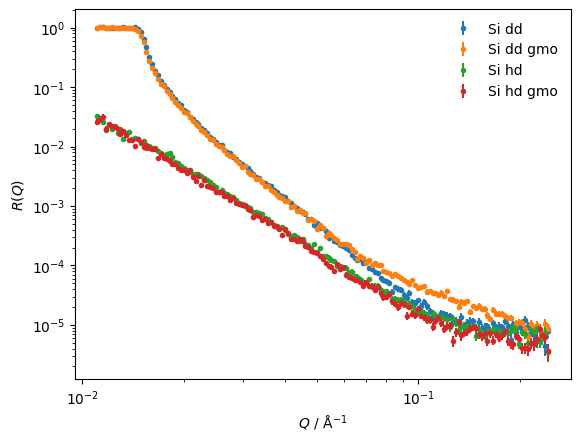

In [6]:
plt.errorbar(x=si_dd_probe.Q, 
             y=si_dd_probe.R, 
             yerr=si_dd_probe.dR, 
             marker='.', 
             linestyle='None',
             label=r'Si dd')
plt.errorbar(x=si_dd_gmo_probe.Q, 
             y=si_dd_gmo_probe.R, 
             yerr=si_dd_gmo_probe.dR, 
             marker='.', 
             linestyle='None',
             label=r'Si dd gmo')
plt.errorbar(x=si_hd_probe.Q, 
             y=si_hd_probe.R, 
             yerr=si_hd_probe.dR, 
             marker='.', 
             linestyle='None',
             label=r'Si hd')
plt.errorbar(x=si_hd_gmo_probe.Q, 
             y=si_hd_gmo_probe.R, 
             yerr=si_hd_gmo_probe.dR, 
             marker='.', 
             linestyle='None',
             label=r'Si hd gmo')
plt.legend(frameon=False)
plt.xscale('log') 
plt.yscale('log')
plt.xlabel(r'$Q$ / $\mathrm{\AA{}}^{-1}$')
plt.ylabel(r'$R\left(Q\right)$')
plt.show()

## The model
We'll model the bare Si data with a fronting of Si, and layer of $\mathrm{SiO}_{2}$ and a solvent backing. An overview of the structure is:

    Si | SiOx | GMO | Dodecane

The SLDs of the materials will be fixed but we'll model the thickness of the $\mathrm{SiO}_{2}$ and the roughness of the interfaces between the materials.

For those contrasts with GMO, we'll model a GMO layer with a fixed SLD of GMO = $0.21 \times 10^{-6} \mathrm{Å}^{-2}$, a varying solvation, thickness and roughness.

There will be the same interface width between $\mathrm{SiO}_{2}$ and the solvent and between $\mathrm{SiO}_{2}$ and GMO.


In [7]:
gmo_sld_new = Parameter(value=0.21, name='gmo_new', vary=False)
ddod_sld_new = Parameter(value=6.7, name='ddod_new', vary=True, bounds=(6,6.7))
hdod_sld_new = Parameter(value=-0.46, name='hdod_new', vary=False)
Si_new = Parameter(value=2.07, name='Si_new', vary=False)
SiO2_new = Parameter(value=3.47, name='SiO2_new', vary=False)

Si = SLD(rho=2.07, name='Si')
SiO2 = SLD(rho=3.47, name='SiO2')
gmo = SLD(rho=gmo_sld_new, name='gmo')

hdod = SLD(rho=hdod_sld_new, name='hdod')
ddod = SLD(rho=ddod_sld_new, name='ddod')

# lets vary the ddod but not the hdod.
ddod.rho.range(6, 6.7)

Parameter(ddod_new)

In [8]:
# define thickness and roughness parameters.
SiO2_thick = Parameter(value=20, name='SiO2_thick', vary=True, bounds=(1, 30))
gmo_thick = Parameter(value=20, name='gmo_thick', vary=True, bounds=(1, 30))

Si_SiO2_rough = Parameter(value=3, name='Si_SiO2_rough', vary=True, bounds=(1, 10))
SiO2_solv_rough = Parameter(5, name='SiO2_solv_rough', vary=True, bounds=(1, 10))

SiO2_gmo_rough = SiO2_solv_rough # Parameter(name='SiO2_gmo_rough', constraint=SiO2_solv_rough)
gmo_solv_rough = Parameter(5, name='gmo_solv_rough', vary=True, bounds=(1, 10))

gmo_vf = Parameter(value=1, name='gmo_vf', vary=True, bounds=(0, 1))


## refl1d works from backing to fronting...

In [9]:
# define the SLDs of the materials in two lists for the two contrasts.
dd_nslds = [Si_new,
            SiO2_new,
            ddod_sld_new]

hd_nslds = [Si_new,
            SiO2_new,
            hdod_sld_new]

dd_gmo_nslds = [Si_new,
                SiO2_new,
                gmo_sld_new * gmo_vf + ddod_sld_new * (1-gmo_vf),
                ddod_sld_new]

hd_gmo_nslds = [Si_new,
                SiO2_new,
                gmo_sld_new * gmo_vf + hdod_sld_new * (1-gmo_vf),
                hdod_sld_new]

# define the thicknesses of the all layers, including the fronting but not the backing.
list_of_thicknesses_bare = [0, SiO2_thick]
list_of_thicknesses_gmo = [0, SiO2_thick, gmo_thick]
# define the width the of the interfaces between the materials.
list_of_roughnesses_bare = [Si_SiO2_rough, SiO2_solv_rough]
list_of_roughnesses_gmo = [Si_SiO2_rough, SiO2_gmo_rough, gmo_solv_rough]

# use the list of SLDs, thicknesses and roughnesses to define refnxVFP objects.
dd_vfp_bare = vfp.refl1dVFP(nslds=dd_nslds,
                            thicknesses=list_of_thicknesses_bare,
                            roughnesses=list_of_roughnesses_bare,
                            orientation='back')

hd_vfp_bare = vfp.refl1dVFP(nslds=hd_nslds,
                            thicknesses=list_of_thicknesses_bare,
                            roughnesses=list_of_roughnesses_bare,
                            orientation='back')

dd_vfp_gmo = vfp.refl1dVFP(nslds=dd_gmo_nslds,
                           thicknesses=list_of_thicknesses_gmo,
                           roughnesses=list_of_roughnesses_gmo,
                           orientation='back')

hd_vfp_gmo = vfp.refl1dVFP(nslds=hd_gmo_nslds,
                           thicknesses=list_of_thicknesses_gmo,
                           roughnesses=list_of_roughnesses_gmo,
                           orientation='back')

/Users/r2i/Library/CloudStorage/OneDrive-OakRidgeNationalLaboratory/Documents/Collaborations/VFP/VFP_seems_broken/src/vfp/vfp.py:1031: UserWarning: If msld / isld parameters are part of a function (i.e f(p1, p2) = p1 + p2), they must be of type bumps.parameter.Parameter. Do not use material or SLD objects.
  warnings.warn(


In [ ]:
# see the parameters in the ref1dVFP
# these contain non varying parameters.
print(dd_vfp_gmo.layer_parameters())

In [ ]:
# the ref1dVFP objects are ref1d Component objects so can be placed in a ref1d structure.
# place vfps between SLD objects.
dd_struc = ddod | dd_vfp_bare | Si
hd_struc = hdod | hd_vfp_bare | Si
dd_GMO_struc = ddod | dd_vfp_gmo | Si
hd_GMO_struc = hdod | hd_vfp_gmo | Si

In [ ]:
# define instrument / nuisance parameters
si_dd_probe.intensity.range(0.8, 1.2)
si_dd_probe.intensity.name = "Si_dd_int"
si_hd_probe.intensity.range(0.8, 1.2)
si_hd_probe.intensity.name = "Si_hd_int"
si_dd_gmo_probe.intensity.range(0.8, 1.2)
si_dd_gmo_probe.intensity.name = "Si_gmo_dd_int"
si_hd_gmo_probe.intensity.range(0.8, 1.2)
si_hd_gmo_probe.intensity.name = "Si_gmo_hd_int"

si_dd_probe.background.value = 1e-5
si_dd_probe.background.range(1e-8, 1e-4)
si_dd_probe.background.name = "Si_dd_bkg"
si_hd_probe.background.value = 1e-5
si_hd_probe.background.range(1e-8, 1e-4)
si_hd_probe.background.name = "Si_hd_bkg"
si_dd_gmo_probe.background.range(1e-8, 1e-4)
si_dd_gmo_probe.background.value = 1e-5
si_dd_gmo_probe.background.name = "Si_gmo_dd_bkg"
si_hd_gmo_probe.background.range(1e-8, 1e-4)
si_hd_gmo_probe.background.value = 1e-5
si_hd_gmo_probe.background.name = "Si_gmo_hd_bkg"

In [ ]:
# define relationships between probes (i.e. data) and sample structures:
exp_si_dd = Experiment(probe=si_dd_probe, sample=dd_struc)
exp_si_hd = Experiment(probe=si_hd_probe, sample=hd_struc)
exp_si_dd_gmo = Experiment(probe=si_dd_gmo_probe, sample=dd_GMO_struc)
exp_si_hd_gmo = Experiment(probe=si_hd_gmo_probe, sample=hd_GMO_struc)

In [ ]:
# define the problem to fit all contrasts:
problem = FitProblem([exp_si_dd, exp_si_hd, exp_si_dd_gmo, exp_si_hd_gmo])

In [ ]:
# check model looks reasonable with starting parameters

%matplotlib inline
for mod in problem.models:
    plt.errorbar(x=mod.probe.Q, y=mod.probe.R, yerr=mod.probe.dR, linestyle='None', marker='.')
    plt.plot(*mod.reflectivity(), color='k', zorder=10)
plt.xscale('log')
plt.yscale('log')
plt.show()

## Fit via `bumps.fitters.fit`.

It's more common to write a `refl1d` script and use the cli or the GUI.
But we can do it interactively...

In [ ]:
from bumps.mapper import MPMapper
from bumps.fitters import fit
mapper = MPMapper.start_mapper(problem, None, cpus=0) # cpu=0 for all CPUs
#result = fit(problem, method="de", mapper=mapper, verbose=True, options=dict(steps=200, pop=160)) # only run for 200 iterations.
result = fit(problem, method="de", verbose=False, options=dict(steps=200, pop=160), parallel=0) # only run for 200 iterations.

In [ ]:
# List all the best fit parameters:
{k: v for k, v in zip(problem.labels(), problem.getp())}

In [ ]:
# the parameters are updated in the problem
np.testing.assert_allclose(problem.getp(), result.x)

## Plot the data & optimized model

In [ ]:
%matplotlib inline
for mod in problem.models:
    plt.errorbar(x=mod.probe.Q, y=mod.probe.R, yerr=mod.probe.dR, linestyle='None', marker='.')
    plt.plot(*mod.reflectivity(), color='k', zorder=10)
plt.xscale('log')
plt.yscale('log')
plt.show()

## Plot the structure of the vfp

Use the vfp's plot method to plot the SLD, volume fraction profile and a stochastic simulation of the interface.

In the current implementation, there is no way to plot the posterior, but this will be added.

In [ ]:
dd_vfp_bare.plot() # equivalent to glob_obj.objectives[0].model.structure.components[1].plot()
plt.show()

In [ ]:
dd_vfp_gmo.plot() # equivalent to glob_obj.objectives[2].model.structure.components[1].plot()
plt.show()